In [1]:
# install and import
!pip install pandas scikit-learn

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
# upload csv files
from google.colab import files
uploaded = files.upload()

Saving SriLanka_Weather_Dataset.csv to SriLanka_Weather_Dataset.csv


In [3]:
# Load and combine main dataset
df = pd.read_csv('SriLanka_Weather_Dataset.csv')
df.head()

,time,weathercode,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,sunset,...,precipitation_hours,windspeed_10m_max,windgusts_10m_max,winddirection_10m_dominant,et0_fao_evapotranspiration,latitude,longitude,elevation,country,city
0,2010-01-01,2,30.0,22.7,26.1,34.4,25.2,29.2,2010-01-01T00:52,2010-01-01T12:35,...,0.0,11.7,27.4,20,4.58,7.0,79.899994,16.0,Sri Lanka,Colombo
1,2010-01-02,51,29.9,23.5,26.2,33.8,26.2,29.8,2010-01-02T00:52,2010-01-02T12:36,...,1.0,13.0,27.0,24,3.84,7.0,79.899994,16.0,Sri Lanka,Colombo
2,2010-01-03,51,29.5,23.2,26.0,34.3,26.3,29.9,2010-01-03T00:53,2010-01-03T12:36,...,3.0,12.3,27.4,16,3.65,7.0,79.899994,16.0,Sri Lanka,Colombo
3,2010-01-04,2,28.9,21.9,25.3,31.6,23.4,27.8,2010-01-04T00:53,2010-01-04T12:37,...,0.0,17.0,34.6,356,3.79,7.0,79.899994,16.0,Sri Lanka,Colombo
4,2010-01-05,1,28.1,21.3,24.5,30.1,23.1,26.1,2010-01-05T00:53,2010-01-05T12:37,...,0.0,18.7,37.1,355,4.97,7.0,79.899994,16.0,Sri Lanka,Colombo


In [4]:
#select and clean data

df = df[['time', 'latitude', 'longitude',
         'temperature_2m_max', 'temperature_2m_min',
         'precipitation_sum', 'windspeed_10m_max']]

df.columns = ['Date', 'Lat', 'Lon', 'Temp_Max', 'Temp_Min', 'Rain', 'Wind']

df = df.dropna()

In [5]:
# fishing score

def fishing_score(row):
    score = 50

    # Temperature condition
    if 24 <= row['Temp_Max'] <= 30:
        score += 20
    else:
        score -= 10

    # Wind condition
    if row['Wind'] < 10:
        score += 20
    elif row['Wind'] < 20:
        score += 5
    else:
        score -= 15

    # Rain condition
    if row['Rain'] == 0:
        score += 15
    elif row['Rain'] < 5:
        score += 5
    else:
        score -= 15

    return max(0, min(100, score))

df['FishingScore'] = df.apply(fishing_score, axis=1)

In [6]:
#convert to labels

def fishing_label(score):
    if score >= 70:
        return 2   # HIGH
    elif score >= 40:
        return 1   # MEDIUM
    else:
        return 0   # LOW

df['FishingLabel'] = df['FishingScore'].apply(fishing_label)

In [7]:
# prepare data
X = df[['Temp_Max', 'Temp_Min', 'Rain', 'Wind', 'Lat', 'Lon']]
y = df['FishingLabel']

In [8]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# train model
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=150, random_state=42)

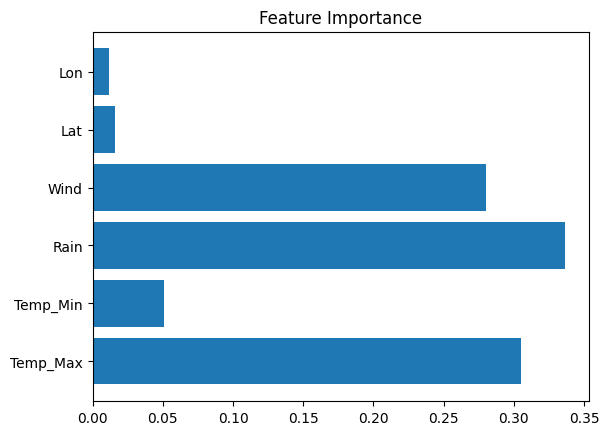

In [10]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [11]:
# accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9999321941958231


In [12]:
# real life test
new_data = pd.DataFrame({
    'Temp_Max':[29],
    'Temp_Min':[24],
    'Rain':[0],
    'Wind':[8],
    'Lat':[6.9],
    'Lon':[79.8]
})

prediction = model.predict(new_data)

labels = ['LOW', 'MEDIUM', 'HIGH']
print("Fishing Condition:", labels[prediction[0]])

Fishing Condition: HIGH


In [13]:
probs = model.predict_proba(new_data)
print("Confidence:", np.max(probs)*100, "%")

Confidence: 100.0 %


In [14]:
import requests

# Example: Colombo / Negombo area
lat = 6.9
lon = 79.8

url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current_weather=true&daily=precipitation_sum&timezone=Asia%2FColombo"

response = requests.get(url)
data = response.json()

# Extract values
temp = data['current_weather']['temperature']
wind = data['current_weather']['windspeed']
rain = data['daily']['precipitation_sum'][0]

print("Live Temperature:", temp)
print("Live Wind Speed:", wind)
print("Live Rain:", rain)

Live Temperature: 29.3
Live Wind Speed: 11.5
Live Rain: 0.3


In [15]:
# Create input for model
new_data = pd.DataFrame({
    'Temp_Max':[temp],
    'Temp_Min':[temp - 3],  # approximate
    'Rain':[rain],
    'Wind':[wind],
    'Lat':[lat],
    'Lon':[lon]
})

prediction = model.predict(new_data)

labels = ['LOW', 'MEDIUM', 'HIGH']
print("Fishing Condition:", labels[prediction[0]])

Fishing Condition: HIGH


In [16]:
# future roadmap: Fish Net Detector
def fish_net_scanner_concept():
    print("--- FUTURE MODULE: AI FISH NET SCANNER ---")
    print("Initializing Computer Vision surface scan...")
    print("Pattern matched: Ripples indicating fish school detected.")
    print("Action: Optimal coordinates for Fish Net deployment ready.")

fish_net_scanner_concept()

--- FUTURE MODULE: AI FISH NET SCANNER ---
Initializing Computer Vision surface scan...
Pattern matched: Ripples indicating fish school detected.
Action: Optimal coordinates for Fish Net deployment ready.
